<div style="background:linear-gradient(135deg,#16213E 0%,#1B2A4A 60%,#0FA3A0 150%);border-radius:14px;padding:28px 32px;color:white;font-family:'Segoe UI',sans-serif;">

<div style="font-size:13px;letter-spacing:3px;color:#F0A500;font-weight:700;">WEEK 7 · SPRINT 2 · PHASE 3 CAPSTONE</div>
<h1 style="margin:6px 0 2px 0;color:white;border:none;">🧬 Day 2 — Building the Diagnostician</h1>
<div style="font-size:18px;color:#D7DEF2;font-style:italic;">From a from-scratch CNN to a fine-tuned, explainable transfer-learning model</div>

<div style="margin-top:14px;font-size:13px;color:#AFC0E8;">
👤 <b>Zayan Shawareb</b> &nbsp;|&nbsp; 🏢 BinX Tech — AI &amp; ML Internship &nbsp;|&nbsp; 🩺 Melanoma Skin Cancer Dataset (Kaggle)
</div>

<div style="margin-top:16px;"><img src="https://img.shields.io/badge/TensorFlow-Keras?style=for-the-badge&logo=tensorflow&logoColor=white" style="margin:2px;"/> <img src="https://img.shields.io/badge/Scikit--learn-Metrics?style=for-the-badge&logo=scikitlearn&logoColor=white" style="margin:2px;"/> <img src="https://img.shields.io/badge/MobileNetV2-ImageNet?style=for-the-badge&logo=google&logoColor=white" style="margin:2px;"/> <img src="https://img.shields.io/badge/Grad--CAM-XAI?style=for-the-badge&logo=opencv&logoColor=white" style="margin:2px;"/></div>

</div>

<div style="display:flex;background:#FFF8EE;border-radius:12px;margin-top:14px;padding:6px 10px;border:1px solid #F0E4D0;">
<div style="flex:1;text-align:center;padding:10px 4px;">
              <div style="font-size:26px;">🏗️</div>
              <div style="font-size:12px;font-weight:600;color:#16213E;margin-top:4px;">Build</div>
            </div><div style="color:#C9CFE0;font-size:20px;padding-top:14px;">→</div><div style="flex:1;text-align:center;padding:10px 4px;">
              <div style="font-size:26px;">🎓</div>
              <div style="font-size:12px;font-weight:600;color:#16213E;margin-top:4px;">Transfer</div>
            </div><div style="color:#C9CFE0;font-size:20px;padding-top:14px;">→</div><div style="flex:1;text-align:center;padding:10px 4px;">
              <div style="font-size:26px;">🩺</div>
              <div style="font-size:12px;font-weight:600;color:#16213E;margin-top:4px;">Evaluate</div>
            </div><div style="color:#C9CFE0;font-size:20px;padding-top:14px;">→</div><div style="flex:1;text-align:center;padding:10px 4px;">
              <div style="font-size:26px;">👁️‍🗨️</div>
              <div style="font-size:12px;font-weight:600;color:#16213E;margin-top:4px;">Explain</div>
            </div>
</div>


<div style="background:#FFF8EE;border:1px solid #F0A50033;border-left:5px solid #F0A500;border-radius:8px;padding:14px 18px;margin:10px 0;">
<div style="font-weight:700;color:#F0A500;font-size:14px;">📖 Continuing the Story</div>
<div style="margin-top:6px;font-size:14px;color:#2B2B2B;">

Yesterday we proved *why* convolution is the right tool and *why* MobileNetV2 is efficient. Today we put that theory to work: we'll build a CNN from scratch as our own internal baseline, progressively make it smarter (augmentation → transfer learning → fine-tuning), and — critically for a **medical** classifier — prove not just that it's accurate, but that it's looking at the right thing.

By the end of this notebook, every model will have a name, a number, and a *reason* it was tried.

</div>
</div>

## 0 · Environment Setup (Google Colab)

Run this once per Colab session. Enable a GPU first: **Runtime → Change runtime type → T4 GPU**.


In [1]:
# Check GPU is active
import tensorflow as tf
print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# --- Kaggle API setup (new token-based auth) ---
import os

KAGGLE_API_TOKEN = "KGAT_9245926882e0508fadca74424afe5d03"
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/access_token', 'w') as f:
    f.write(KAGGLE_API_TOKEN)
os.chmod('/root/.kaggle/access_token', 0o600)

!pip install -q --upgrade kaggle
!kaggle --version


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 4.9 MB/s eta 0:00:00
Kaggle CLI 2.2.4


In [3]:
# Download the melanoma dataset
!kaggle datasets download -d ailearner-researchlab/melanoma-skin-cancer-dataset-benign-vs-malignant -p /content/data --unzip
!find /content/data -maxdepth 3 -type d


Dataset URL: https://www.kaggle.com/datasets/ailearner-researchlab/melanoma-skin-cancer-dataset-benign-vs-malignant
License(s): MIT
100% 79.4M/79.4M [00:02<00:00, 33.5MB/s]

/content/data
/content/data/train
/content/data/train/Benign
/content/data/train/Malignant
/content/data/test
/content/data/test/Benign
/content/data/test/Malignant


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Sequential, Model
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import (confusion_matrix, roc_curve, auc,
                              classification_report, ConfusionMatrixDisplay)
import pathlib, random

# Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DATA_DIR = pathlib.Path('/content/data')  # adjust if the unzip nests a subfolder
print(list(DATA_DIR.glob('*')))


[PosixPath('/content/data/train'), PosixPath('/content/data/test')]


---
# 📅 DAY 2 — Building CNNs & Transfer Learning


<div style="border-left:6px solid #0FA3A0;background:#E8F7F5;padding:10px 18px;border-radius:0 8px 8px 0;margin-top:8px;">
<span style="font-size:12px;font-weight:700;letter-spacing:2px;color:#0FA3A0;">SECTION 2.1</span>
<h2 style="margin:2px 0 0 0;border:none;padding:0;">🔍 Loading the Dataset & Exploratory Check</h2>
</div>

In [5]:
IMG_SIZE = 128
BATCH_SIZE = 32

# Adjust these paths after inspecting the extracted folder structure printed earlier
TRAIN_DIR = DATA_DIR / 'train'
TEST_DIR  = DATA_DIR / 'test'

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=0.2, subset="training", seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, label_mode='binary'
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=0.2, subset="validation", seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, label_mode='binary'
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    label_mode='binary', shuffle=False
)

class_names = train_ds.class_names
print("Classes:", class_names)


Found 11879 files belonging to 2 classes.
Using 9504 files for training.
Found 11879 files belonging to 2 classes.
Using 2375 files for validation.
Found 2000 files belonging to 2 classes.
Classes: ['Benign', 'Malignant']


/tmp/ipykernel_1364/491563555.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  counts[int(labels.numpy())] += 1


Benign: 5059 images (53.2%)
Malignant: 4445 images (46.8%)


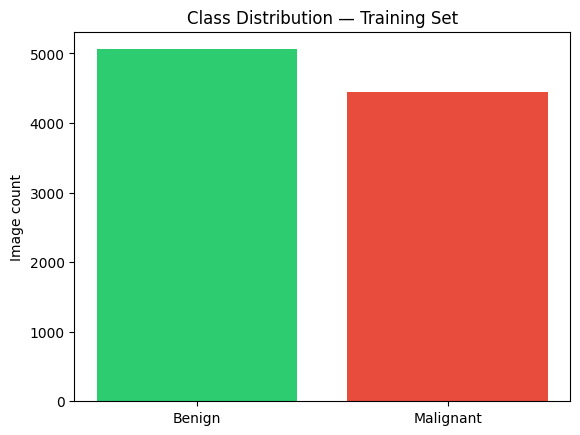

In [6]:
# Class balance check
import collections
counts = collections.Counter()
for _, labels in train_ds.unbatch():
    counts[int(labels.numpy())] += 1

total = sum(counts.values())
for cls_idx, name in enumerate(class_names):
    n = counts[cls_idx]
    print(f"{name}: {n} images ({n/total:.1%})")

plt.bar(class_names, [counts[i] for i in range(len(class_names))], color=['#2ECC71','#E74C3C'])
plt.title("Class Distribution — Training Set")
plt.ylabel("Image count")
plt.show()


<div style="background:#FFF4E5;border:1px solid #FF6B4733;border-left:5px solid #FF6B47;border-radius:8px;padding:14px 18px;margin:10px 0;">
<div style="font-weight:700;color:#FF6B47;font-size:14px;">⚠️ Read this before training anything</div>
<div style="margin-top:6px;font-size:14px;color:#2B2B2B;">

If the bars above are uneven, **accuracy will lie to you**. A model that always predicts the majority class can still score high accuracy while being medically useless. Keep §2.5 (class weights) and §2.8 (recall, not just accuracy) in mind for everything that follows.

</div>
</div>

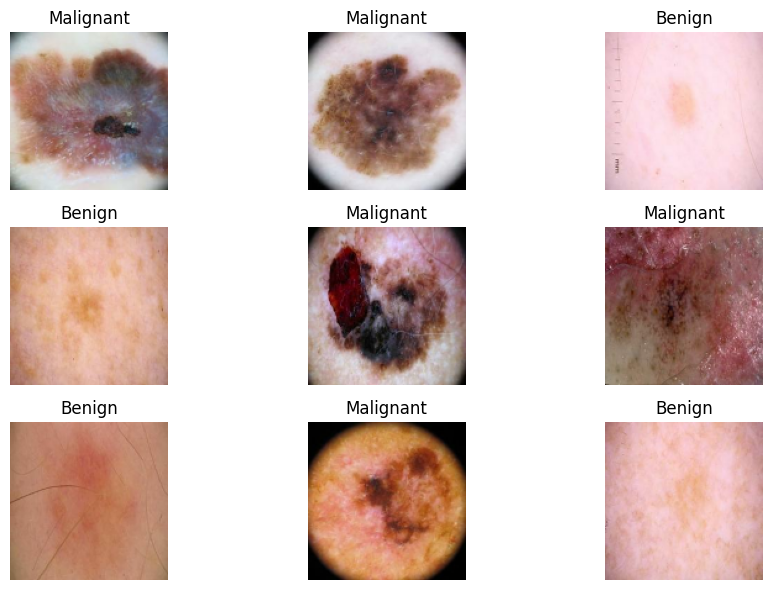

In [7]:
# Peek at sample images
plt.figure(figsize=(10, 6))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")
plt.tight_layout(); plt.show()


In [8]:
# Performance: prefetching (standard tf.data best practice, not in the base curriculum)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Rescaling layer — shared by all models below
rescale = layers.Rescaling(1./255)


<div style="border-left:6px solid #0FA3A0;background:#E8F7F5;padding:10px 18px;border-radius:0 8px 8px 0;margin-top:8px;">
<span style="font-size:12px;font-weight:700;letter-spacing:2px;color:#0FA3A0;">SECTION 2.2</span>
<h2 style="margin:2px 0 0 0;border:none;padding:0;">📒 The Results Ledger — No Experiment Left Untracked</h2>
</div>

In [9]:
results_log = []

def log_result(name, history, test_metrics_dict, notes=""):
    results_log.append({
        "model": name,
        "final_val_acc": round(history.history['val_accuracy'][-1], 4),
        "final_val_loss": round(history.history['val_loss'][-1], 4),
        **test_metrics_dict,
        "notes": notes
    })
    import pandas as pd
    return pd.DataFrame(results_log)


<div style="border-left:6px solid #0FA3A0;background:#E8F7F5;padding:10px 18px;border-radius:0 8px 8px 0;margin-top:8px;">
<span style="font-size:12px;font-weight:700;letter-spacing:2px;color:#0FA3A0;">SECTION 2.3</span>
<h2 style="margin:2px 0 0 0;border:none;padding:0;">🏗️ Baseline CNN — Built From Scratch</h2>
</div>

In [10]:
def build_scratch_cnn():
    model = Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        rescale,
        layers.Conv2D(32, 3, activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, activation='relu'),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid'),
    ], name="scratch_cnn")
    model.compile(optimizer='adam', loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                           tf.keras.metrics.Recall(name='recall')])
    return model

scratch_model = build_scratch_cnn()
scratch_model.summary()


Model: "scratch_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,605,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,699,009 (6.48 MB)

 Trainable params: 1,699,009 (6.48 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_scratch = scratch_model.fit(
    train_ds, validation_data=val_ds, epochs=25, callbacks=[early_stop]
)


Epoch 1/25
297/297 ━━━━━━━━━━━━━━━━━━━━ 35s 42ms/step - accuracy: 0.7536 - auc: 0.8387 - loss: 0.4919 - recall: 0.6904 - val_accuracy: 0.7541 - val_auc: 0.9168 - val_loss: 0.4785 - val_recall: 0.9721
Epoch 2/25
297/297 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.8228 - auc: 0.8954 - loss: 0.4089 - recall: 0.7939 - val_accuracy: 0.8316 - val_auc: 0.9184 - val_loss: 0.3770 - val_recall: 0.8926
Epoch 3/25
297/297 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8354 - auc: 0.9081 - loss: 0.3864 - recall: 0.8099 - val_accuracy: 0.7945 - val_auc: 0.9230 - val_loss: 0.4088 - val_recall: 0.9432
Epoch 4/25
297/297 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.8419 - auc: 0.9147 - loss: 0.3693 - recall: 0.8331 - val_accuracy: 0.8198 - val_auc: 0.9151 - val_loss: 0.3888 - val_recall: 0.7144
Epoch 5/25
297/297 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8476 - auc: 0.9252 - loss: 0.3479 - recall: 0.8430 - val_accuracy: 0.8408 - val_auc: 0.9286 - val_loss: 0.3432 - val_recall: 0.8690
Epo

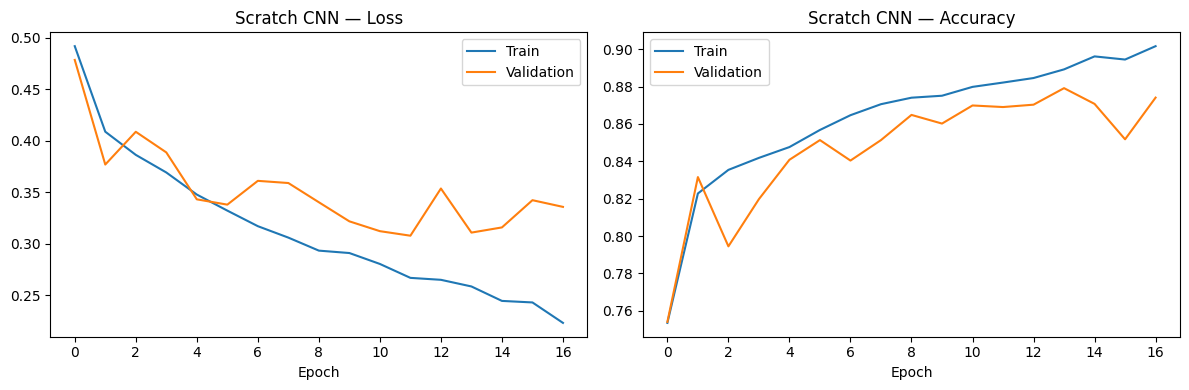

In [12]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history['loss'], label='Train')
    axes[0].plot(history.history['val_loss'], label='Validation')
    axes[0].set_title(f'{title} — Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

    axes[1].plot(history.history['accuracy'], label='Train')
    axes[1].plot(history.history['val_accuracy'], label='Validation')
    axes[1].set_title(f'{title} — Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()
    plt.tight_layout(); plt.show()

plot_history(history_scratch, "Scratch CNN")


<div style="border-left:6px solid #0FA3A0;background:#E8F7F5;padding:10px 18px;border-radius:0 8px 8px 0;margin-top:8px;">
<span style="font-size:12px;font-weight:700;letter-spacing:2px;color:#0FA3A0;">SECTION 2.4</span>
<h2 style="margin:2px 0 0 0;border:none;padding:0;">🔄 Data Augmentation — Does It Actually Help?</h2>
</div>

Epoch 1/25
297/297 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.7395 - auc: 0.8039 - loss: 0.5334 - recall: 0.6373 - val_accuracy: 0.8101 - val_auc: 0.9006 - val_loss: 0.4301 - val_recall: 0.8812
Epoch 2/25
297/297 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.8086 - auc: 0.8858 - loss: 0.4268 - recall: 0.7861 - val_accuracy: 0.8232 - val_auc: 0.9150 - val_loss: 0.3955 - val_recall: 0.7301
Epoch 3/25
297/297 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.8263 - auc: 0.9033 - loss: 0.3953 - recall: 0.8178 - val_accuracy: 0.8362 - val_auc: 0.9242 - val_loss: 0.3684 - val_recall: 0.7729
Epoch 4/25
297/297 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.8324 - auc: 0.9088 - loss: 0.3849 - recall: 0.8261 - val_accuracy: 0.8371 - val_auc: 0.9240 - val_loss: 0.3767 - val_recall: 0.7598
Epoch 5/25
297/297 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.8408 - auc: 0.9126 - loss: 0.3764 - recall: 0.8353 - val_accuracy: 0.8324 - val_auc: 0.9120 - val_loss: 0.3827 - val_recall: 0.8192


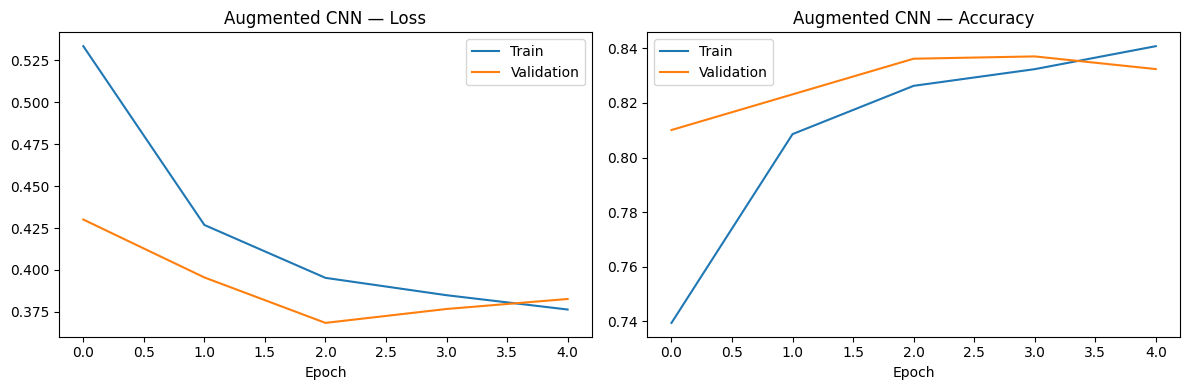

In [13]:
data_augmentation = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1),
], name="augmentation")

def build_augmented_cnn():
    model = Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        data_augmentation,
        rescale,
        layers.Conv2D(32, 3, activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, activation='relu'),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid'),
    ], name="augmented_cnn")
    model.compile(optimizer='adam', loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                           tf.keras.metrics.Recall(name='recall')])
    return model

aug_model = build_augmented_cnn()
history_aug = aug_model.fit(train_ds, validation_data=val_ds, epochs=25, callbacks=[early_stop])
plot_history(history_aug, "Augmented CNN")


<div style="border-left:6px solid #F0A500;background:#FFF8EE;padding:10px 18px;border-radius:0 8px 8px 0;margin-top:8px;">
<span style="font-size:12px;font-weight:700;letter-spacing:2px;color:#F0A500;">SECTION 2.5</span>
<h2 style="margin:2px 0 0 0;border:none;padding:0;">⚖️ Handling Class Imbalance — Class Weights</h2>
</div>

In [14]:
from sklearn.utils.class_weight import compute_class_weight

labels_list = [counts[i] for i in range(len(class_names))]
class_weight_values = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(class_names)),
    y=np.concatenate([np.full(labels_list[i], i) for i in range(len(class_names))])
)
class_weight_dict = {i: w for i, w in enumerate(class_weight_values)}
print("Class weights:", class_weight_dict, "-> classes:", class_names)


Class weights: {0: np.float64(0.9393160703696383), 1: np.float64(1.069066366704162)} -> classes: ['Benign', 'Malignant']


<div style="background:#EAF6FF;border:1px solid #2E86DE33;border-left:5px solid #2E86DE;border-radius:8px;padding:14px 18px;margin:10px 0;">
<div style="font-weight:700;color:#2E86DE;font-size:14px;">💡 Insight</div>
<div style="margin-top:6px;font-size:14px;color:#2B2B2B;">

These weights tell the loss function: *'a mistake on the minority class costs more.'* This is a one-line fix (`class_weight=...` in `.fit()`) with an outsized real-world impact for a screening tool.

</div>
</div>

<div style="border-left:6px solid #0FA3A0;background:#E8F7F5;padding:10px 18px;border-radius:0 8px 8px 0;margin-top:8px;">
<span style="font-size:12px;font-weight:700;letter-spacing:2px;color:#0FA3A0;">SECTION 2.6</span>
<h2 style="margin:2px 0 0 0;border:none;padding:0;">🎓 Transfer Learning — MobileNetV2 (Frozen Base)</h2>
</div>

In [15]:
def build_transfer_model(fine_tune=False, fine_tune_at=100):
    base = MobileNetV2(include_top=False, weights='imagenet',
                        input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base.trainable = fine_tune
    if fine_tune:
        for layer in base.layers[:fine_tune_at]:
            layer.trainable = False

    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = data_augmentation(inputs)
    x = tf.keras.applications.mobilenet_v2.preprocess_input(x)  # MobileNet's own preprocessing, NOT our rescale layer
    x = base(x, training=fine_tune)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    model = Model(inputs, outputs, name="mobilenetv2_transfer")

    lr = 1e-5 if fine_tune else 1e-3
    model.compile(optimizer=tf.keras.optimizers.Adam(lr),
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                           tf.keras.metrics.Recall(name='recall')])
    return model, base

transfer_model, base_model = build_transfer_model(fine_tune=False)
transfer_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "mobilenetv2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 15s 34ms/step - accuracy: 0.7765 - auc: 0.8609 - loss: 0.4711 - recall: 0.7701 - val_accuracy: 0.8354 - val_auc: 0.9156 - val_loss: 0.3763 - val_recall: 0.7729
Epoch 2/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.8331 - auc: 0.9086 - loss: 0.3833 - recall: 0.8187 - val_accuracy: 0.8051 - val_auc: 0.9255 - val_loss: 0.4119 - val_recall: 0.6550
Epoch 3/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.8340 - auc: 0.9137 - loss: 0.3737 - recall: 0.8243 - val_accuracy: 0.8265 - val_auc: 0.9290 - val_loss: 0.3758 - val_recall: 0.7100
Epoch 4/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.8412 - auc: 0.9208 - loss: 0.3571 - recall: 0.8295 - val_accuracy: 0.8303 - val_auc: 0.9301 - val_loss: 0.3642 - val_recall: 0.7275
Epoch 5/15
297/297 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.8380 - auc: 0.9206 - loss: 0.3572 - recall: 0.8247 - val_accuracy: 0.8232 - val_auc: 0.9322 - val_loss: 0.3799 - val_recall: 0.6978
Tra

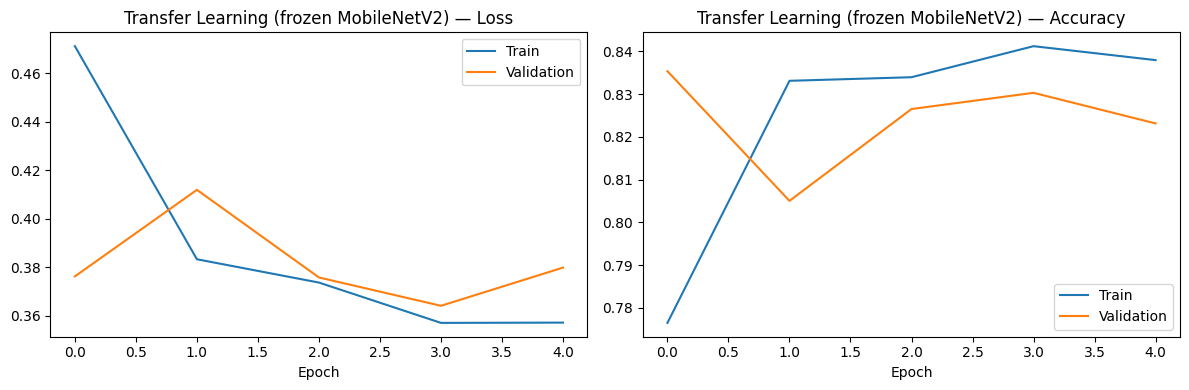

In [16]:
import time
t0 = time.time()
history_transfer = transfer_model.fit(
    train_ds, validation_data=val_ds, epochs=15,
    class_weight=class_weight_dict, callbacks=[early_stop]
)
transfer_train_time = time.time() - t0
print(f"Transfer learning training time: {transfer_train_time:.1f}s")
plot_history(history_transfer, "Transfer Learning (frozen MobileNetV2)")


<div style="border-left:6px solid #0FA3A0;background:#E8F7F5;padding:10px 18px;border-radius:0 8px 8px 0;margin-top:8px;">
<span style="font-size:12px;font-weight:700;letter-spacing:2px;color:#0FA3A0;">SECTION 2.7</span>
<h2 style="margin:2px 0 0 0;border:none;padding:0;">🔧 Fine-Tuning — Unfreezing the Top Layers</h2>
</div>

Epoch 1/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 25s 46ms/step - accuracy: 0.7568 - auc: 0.8812 - loss: 0.5213 - recall: 0.9028 - val_accuracy: 0.7899 - val_auc: 0.9127 - val_loss: 0.5037 - val_recall: 0.6070
Epoch 2/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 16s 54ms/step - accuracy: 0.8247 - auc: 0.9083 - loss: 0.3972 - recall: 0.8416 - val_accuracy: 0.8164 - val_auc: 0.9209 - val_loss: 0.4377 - val_recall: 0.6707
Epoch 3/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step - accuracy: 0.8434 - auc: 0.9208 - loss: 0.3632 - recall: 0.8463 - val_accuracy: 0.8244 - val_auc: 0.9268 - val_loss: 0.4124 - val_recall: 0.6969
Epoch 4/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 12s 42ms/step - accuracy: 0.8511 - auc: 0.9277 - loss: 0.3442 - recall: 0.8506 - val_accuracy: 0.8341 - val_auc: 0.9329 - val_loss: 0.3900 - val_recall: 0.7223
Epoch 5/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 12s 42ms/step - accuracy: 0.8553 - auc: 0.9318 - loss: 0.3364 - recall: 0.8547 - val_accuracy: 0.8484 - val_auc: 0.9383 - val_loss: 0.3558 - val_recall: 0.7598


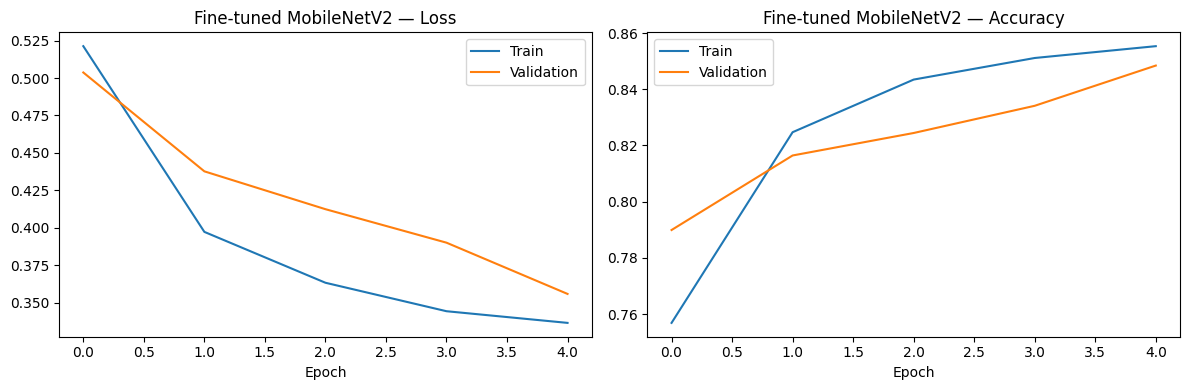

In [17]:
transfer_model.get_layer('mobilenet_1.00_128' if 'mobilenet_1.00_128' in [l.name for l in transfer_model.layers] else base_model.name).trainable = True

# Freeze everything except the last ~30 layers of the base
for layer in base_model.layers[:-30]:
    layer.trainable = False

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  # much lower LR for fine-tuning
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc'), tf.keras.metrics.Recall(name='recall')]
)

history_finetune = transfer_model.fit(
    train_ds, validation_data=val_ds, epochs=10,
    class_weight=class_weight_dict, callbacks=[early_stop]
)
plot_history(history_finetune, "Fine-tuned MobileNetV2")


<div style="border-left:6px solid #FF6B47;background:#FFF8EE;padding:10px 18px;border-radius:0 8px 8px 0;margin-top:8px;">
<span style="font-size:12px;font-weight:700;letter-spacing:2px;color:#FF6B47;">SECTION 2.8</span>
<h2 style="margin:2px 0 0 0;border:none;padding:0;">🩺 Medical-Grade Evaluation — Beyond Accuracy</h2>
</div>


==================== Scratch CNN ====================
              precision    recall  f1-score   support

      Benign       0.83      0.94      0.88      1000
   Malignant       0.93      0.81      0.87      1000

    accuracy                           0.88      2000
   macro avg       0.88      0.88      0.87      2000
weighted avg       0.88      0.88      0.87      2000



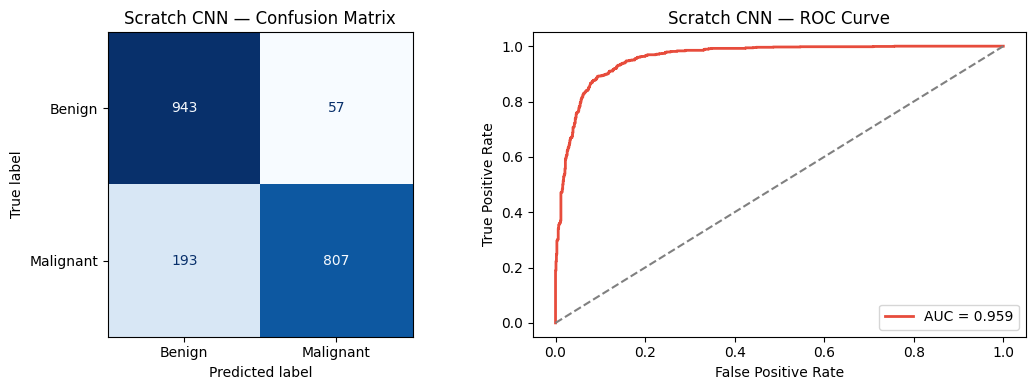


==================== Augmented CNN ====================
              precision    recall  f1-score   support

      Benign       0.82      0.78      0.80      1000
   Malignant       0.79      0.83      0.81      1000

    accuracy                           0.81      2000
   macro avg       0.81      0.80      0.80      2000
weighted avg       0.81      0.81      0.80      2000



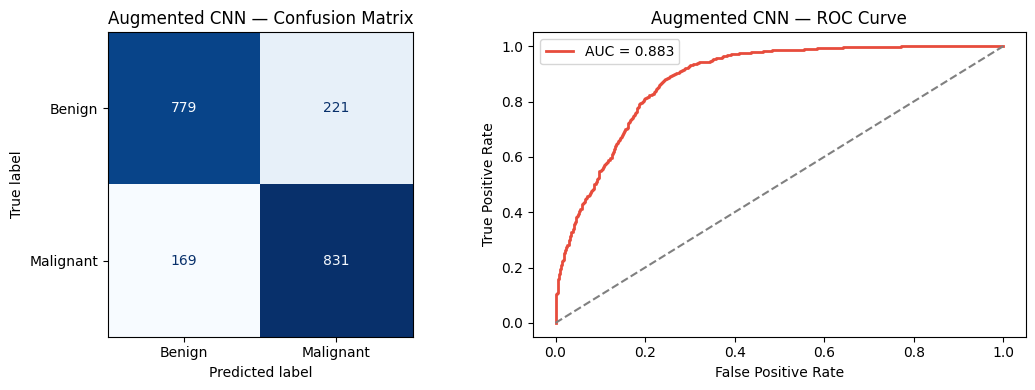


==================== Fine-tuned MobileNetV2 ====================
              precision    recall  f1-score   support

      Benign       0.65      0.97      0.78      1000
   Malignant       0.93      0.47      0.63      1000

    accuracy                           0.72      2000
   macro avg       0.79      0.72      0.70      2000
weighted avg       0.79      0.72      0.70      2000



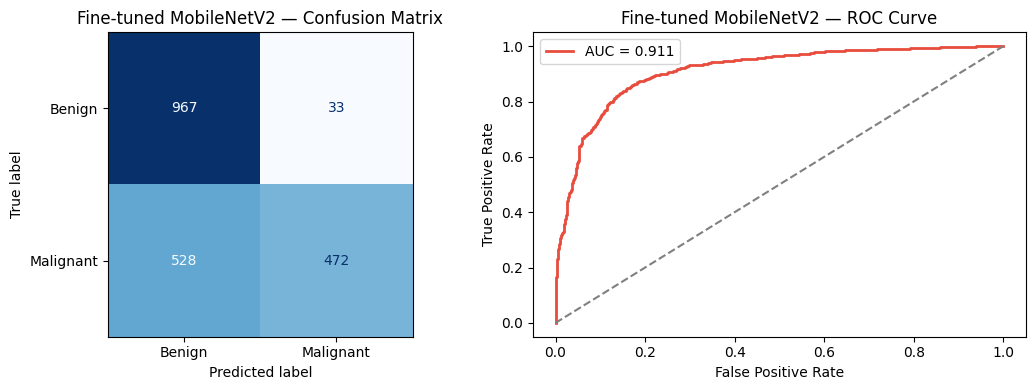

In [18]:
def evaluate_medical(model, dataset, name):
    y_true, y_pred_proba = [], []
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_true.extend(labels.numpy().flatten())
        y_pred_proba.extend(preds.flatten())
    y_true = np.array(y_true)
    y_pred_proba = np.array(y_pred_proba)
    y_pred = (y_pred_proba > 0.5).astype(int)

    print(f"\n{'='*20} {name} {'='*20}")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=axes[0], cmap='Blues', colorbar=False)
    axes[0].set_title(f"{name} — Confusion Matrix")

    axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}', color='#E74C3C', linewidth=2)
    axes[1].plot([0,1],[0,1], linestyle='--', color='gray')
    axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f"{name} — ROC Curve"); axes[1].legend()
    plt.tight_layout(); plt.show()

    return {"test_auc": round(roc_auc, 4), "test_accuracy": round((y_pred == y_true).mean(), 4)}

metrics_scratch   = evaluate_medical(scratch_model, test_ds, "Scratch CNN")
metrics_aug       = evaluate_medical(aug_model, test_ds, "Augmented CNN")
metrics_transfer  = evaluate_medical(transfer_model, test_ds, "Fine-tuned MobileNetV2")


<div style="background:#EAF9EE;border:1px solid #2ECC7133;border-left:5px solid #2ECC71;border-radius:8px;padding:14px 18px;margin:10px 0;">
<div style="font-weight:700;color:#2ECC71;font-size:14px;">✅ Reading the ROC curve like a clinician</div>
<div style="margin-top:6px;font-size:14px;color:#2B2B2B;">

The closer the curve hugs the top-left corner, the better the model separates benign from malignant *at every possible decision threshold* — not just the default 0.5 cutoff. This matters clinically: a doctor might deliberately lower the threshold to catch more malignant cases at the cost of more false alarms.

</div>
</div>

<div style="border-left:6px solid #7B5EA7;background:#FFF8EE;padding:10px 18px;border-radius:0 8px 8px 0;margin-top:8px;">
<span style="font-size:12px;font-weight:700;letter-spacing:2px;color:#7B5EA7;">SECTION 2.9</span>
<h2 style="margin:2px 0 0 0;border:none;padding:0;">👁️‍🗨️ Grad-CAM — What Is the Network Actually Looking At?</h2>
</div>

/tmp/ipykernel_1364/3291916775.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  sample_label = int(labels[0].numpy())
/tmp/ipykernel_1364/3291916775.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


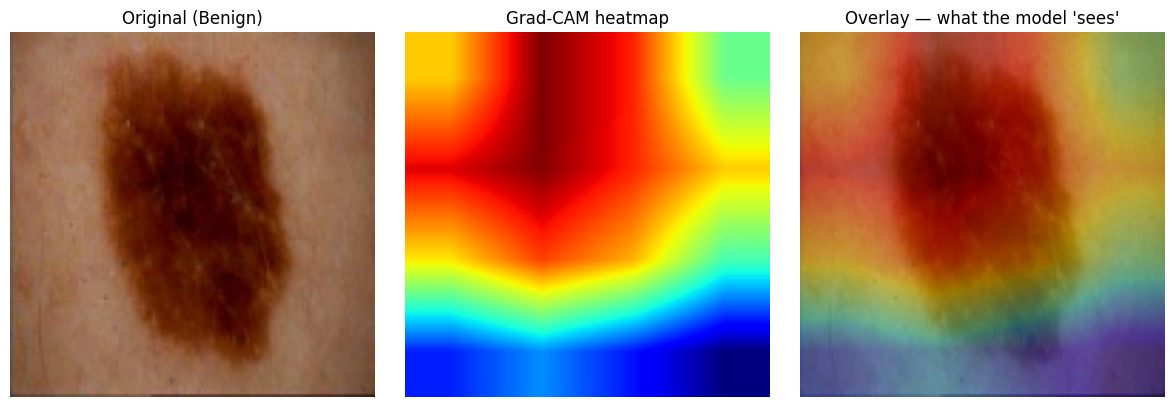

In [19]:
def make_gradcam_heatmap(img_array, model, base_model, last_conv_layer_name=None):
    if last_conv_layer_name is None:
        for layer in reversed(base_model.layers):
            if isinstance(layer, tf.keras.layers.Conv2D):
                last_conv_layer_name = layer.name
                break

    grad_model = Model(
        inputs=base_model.inputs,
        outputs=[base_model.get_layer(last_conv_layer_name).output, base_model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

# Grad-CAM needs access to the base model's own forward pass, so we build a small
# preprocessing-only step separately, then feed the preprocessed image into base_model directly.
for images, labels in test_ds.take(1):
    sample_img = images[0:1]
    sample_label = int(labels[0].numpy())
    break

preprocessed = tf.keras.applications.mobilenet_v2.preprocess_input(data_augmentation(sample_img, training=False))
heatmap = make_gradcam_heatmap(preprocessed, transfer_model, base_model)

import matplotlib.cm as cm
heatmap_resized = tf.image.resize(heatmap[..., np.newaxis], (IMG_SIZE, IMG_SIZE)).numpy().squeeze()
jet = cm.get_cmap("jet")
jet_heatmap = jet(heatmap_resized)[:, :, :3]

original = sample_img[0].numpy().astype("uint8")
overlay = (jet_heatmap * 255 * 0.4 + original * 0.6).astype("uint8")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(original); axes[0].set_title(f"Original ({class_names[sample_label]})")
axes[1].imshow(heatmap_resized, cmap='jet'); axes[1].set_title("Grad-CAM heatmap")
axes[2].imshow(overlay); axes[2].set_title("Overlay — what the model 'sees'")
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()


<div style="background:#F3EEFA;border:1px solid #7B5EA733;border-left:5px solid #7B5EA7;border-radius:8px;padding:14px 18px;margin:10px 0;">
<div style="font-weight:700;color:#7B5EA7;font-size:14px;">🔬 Why this single image might be the most important cell in the notebook</div>
<div style="margin-top:6px;font-size:14px;color:#2B2B2B;">

A documented failure mode in real dermatology AI research: models that quietly learned to key off ruler marks, ink borders, or lighting vignettes instead of the lesion itself — and still scored well on accuracy. Grad-CAM is the difference between *'it works'* and *'it works for the right reason.'* If the heatmap lights up the lesion itself, that's real evidence of trustworthy reasoning — not just a good test score.

</div>
</div>

<div style="border-left:6px solid #2ECC71;background:#FFF8EE;padding:10px 18px;border-radius:0 8px 8px 0;margin-top:8px;">
<span style="font-size:12px;font-weight:700;letter-spacing:2px;color:#2ECC71;">SECTION 2.10</span>
<h2 style="margin:2px 0 0 0;border:none;padding:0;">🏆 Final Comparison Table</h2>
</div>

In [20]:
results_table = log_result("Scratch CNN", history_scratch, metrics_scratch)
results_table = log_result("Augmented CNN", history_aug, metrics_aug)
results_table = log_result("Fine-tuned MobileNetV2 (transfer + fine-tune)", history_finetune, metrics_transfer,
                            notes=f"class-weighted, trained in {transfer_train_time:.0f}s frozen phase")
results_table


,model,final_val_acc,final_val_loss,test_auc,test_accuracy,notes
0,Scratch CNN,0.8741,0.3359,0.9589,0.8750,
1,Augmented CNN,0.8324,0.3827,0.8831,0.8050,
2,Fine-tuned MobileNetV2 (transfer + fine-tune),0.8484,0.3558,0.9109,0.7195,"class-weighted, trained in 52s frozen phase"


In [21]:
best_model_name = results_table.sort_values('test_auc', ascending=False).iloc[0]['model']
print(f"🏆 Best model by test AUC: {best_model_name}")
results_table.sort_values('test_auc', ascending=False)


🏆 Best model by test AUC: Scratch CNN


,model,final_val_acc,final_val_loss,test_auc,test_accuracy,notes
0,Scratch CNN,0.8741,0.3359,0.9589,0.8750,
2,Fine-tuned MobileNetV2 (transfer + fine-tune),0.8484,0.3558,0.9109,0.7195,"class-weighted, trained in 52s frozen phase"
1,Augmented CNN,0.8324,0.3827,0.8831,0.8050,


<div style="border-left:6px solid #2ECC71;background:#FFF8EE;padding:10px 18px;border-radius:0 8px 8px 0;margin-top:8px;">
<span style="font-size:12px;font-weight:700;letter-spacing:2px;color:#2ECC71;">SECTION 2.11</span>
<h2 style="margin:2px 0 0 0;border:none;padding:0;">🧠 Documented Decision</h2>
</div>

---
### 📎 Git workflow reminder
```bash
git checkout -b week7/day2
git add day2.ipynb
git commit -m "Week 7 Day 2: CNN from scratch, augmentation, transfer learning + fine-tuning on melanoma dataset, with Grad-CAM explainability"
git push origin week7/day2
# then open a draft PR for the Day 3 mentor code review
```


<div style="background:linear-gradient(135deg,#16213E,#22335C);border-radius:14px;padding:26px 30px;color:white;margin-top:20px;">
<div style="font-size:12px;letter-spacing:3px;color:#F0A500;font-weight:700;">🎬 DIRECTOR'S COMMENTARY</div>
<h2 style="color:white;border:none;margin:6px 0 12px 0;">The Verdict</h2>
<div style="font-size:14px;line-height:1.7;color:#E4E9F7;">

We didn't just build one model — we built an **argument**, model by model:

1. A **from-scratch CNN** to prove we understand the architecture (§2.3).
2. **Augmentation** to test whether more varied training views help (§2.4).
3. **Class weights** because a screening tool cannot afford to be quietly biased toward "benign" (§2.5).
4. **Transfer learning** because a small medical dataset can't out-train ImageNet's millions of images from scratch (§2.6).
5. **Fine-tuning** to let the pre-trained features specialize on lesion textures specifically (§2.7).
6. **ROC-AUC and recall**, not just accuracy, because a missed malignant case is not the same mistake as a false alarm (§2.8).
7. **Grad-CAM**, because a medical model that can't show its reasoning isn't one anyone should trust (§2.9).

The best model isn't just the one with the highest number — it's the one we can *explain*.

</div>
<div style="margin-top:16px;padding-top:14px;border-top:1px solid #3A4A78;font-size:13px;color:#F0A500;">
▶️ Next up: Day 3 — sequential data. Same rigor, new architecture: RNNs and LSTMs.
</div>
</div>